# Errors in code prompts

In [36]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import pandas as pd
import json
import os

from gsm_benchmarker.results_analyser import MultiVariantMultiModelResultsAnalyser
from gsm_benchmarker.results_analyser.utils import pandas_to_latex
from gsm_benchmarker.benchmark.answer_extractor import AnswerExtractor

plt.style.use('seaborn-v0_8-muted')
plt.style.use('seaborn-v0_8-darkgrid')


In [37]:
ERROR_COLOURS = {
    'NUMERICAL_ERROR': '#0f0f2f',
    # code errors
    'NAME_ERROR': 'tab:blue',
    'TYPE_VALUE_ERROR': 'tab:green',
    'SYNTAX_ERROR': 'tab:red',
    'ATTRIBUTE_ERROR': 'tab:cyan',
    'ZERO_DIVISION_ERROR': 'tab:olive',
    'NONE_RETURNED': 'tab:orange',
    'NOT_A_NUMBER': 'tab:purple',
    # nl errors
    'LAST_NUMBER_NUMERICAL_ERROR': 'tab:gray',
    'EMPTY_RESPONSE': 'tab:olive',
    'EMPTY_AFTER_TRIM': 'tab:cyan',
    'NO_NUMBER': 'tab:orange',
    # other
    'Other': '#ca9161'              # Brown (for any catch-all category)
}

colours_list = list(ERROR_COLOURS.values())
colours_code_labels = list(ERROR_COLOURS.keys())

ERROR_NAMES = {
    'NUMERICAL_ERROR': 'Wrong answer',
    'NAME_ERROR': 'Name E.',
    'TYPE_VALUE_ERROR': 'Type/Value E.',
    'SYNTAX_ERROR': 'Syntax E.',
    'ATTRIBUTE_ERROR': 'Attribute E.',
    'NONE_RETURNED': 'None returned',
    'NOT_A_NUMBER': 'Not a number',
    'ZERO_DIVISION_ERROR': '0-division',
    'EMPTY_RESPONSE': 'Empty response',
    'EMPTY_AFTER_TRIM': 'Empty (after trimming)',
    'NO_NUMBER': 'No number found',
    'LAST_NUMBER_NUMERICAL_ERROR': 'Wrong answer - last number',
    'Other': '(Other)'
}

In [38]:
MODELS = ['phi-2',
 'Phi-3.5-mini-instruct',
 'gemma-2b',
 'gemma-2-9b',
 'Mathstral-7B-v0.1',
 'Meta-Llama-3-8B-Instruct',
 'gemma-7b-it',
 'Meta-Llama-3-8B',
 'Mistral-7B-Instruct-v0.1',
 'gemma-2-2b']

In [39]:
with open('mirzadeh-data.json') as f:
    original_results_df = pd.DataFrame(json.load(f))
    original_model_order = original_results_df.model.tolist()

original_model_order

['gemma-2b',
 'gemma-2b-it',
 'gemma-7b',
 'gemma-7b-it',
 'gemma-2-2b',
 'gemma-2-2b-it',
 'gemma-2-9b',
 'gemma-2-9b-it',
 'gemma-2-27b-it',
 'phi-2',
 'Phi-3-mini-128k-instruct',
 'Phi-3-small-128k-instruct',
 'Phi-3-medium-128k-instruct',
 'Phi-3.5-mini-instruct',
 'Mistral-7B-v0.1',
 'Mistral-7B-Instruct-v0.1',
 'Mistral-7B-v0.3',
 'Mistral-7B-Instruct-v0.3',
 'Mathstral-7B-v0.1',
 'Meta-Llama-3-8B',
 'Meta-Llama-3-8B-Instruct',
 'GPT-4o-mini',
 'GPT-4o',
 'o1-mini',
 'o1-preview']

In [40]:
OUTPUTS = Path("results_pres/outputs").resolve()
os.makedirs(OUTPUTS, exist_ok=True)
OUTPUTS_FOLDER = str(OUTPUTS) + "/"

In [41]:
pp = Path("../../../data/gsm-symbolic/outputs").resolve()

folders = {
    'GSM':  "noq_default_full__12_05/final",
    'Simple NL':  "noq_nonformalised__12_05/final",
    'Structured NL':  "noq_formalised__12_05/final",
    'Simple code': "noq_code_short__12_05/final",
    'Structured code': "noq_code_long__12_05/final"
}


In [42]:
res = {k: MultiVariantMultiModelResultsAnalyser(pp/v).variants['main'] for k, v in folders.items()}
errors = {k: v.get_failed_answer_cases(models=MODELS, numerical_errors=True).drop('index', axis=1) for k, v in res.items()}

100%|██████████| 2/2 [00:00<00:00,  2.99it/s]


In [43]:
res['Structured NL'].full_data.detected_result_pattern.unique()

array(['EMPTY_RESPONSE', 'LAST_NUMBER', 'GSM_SYMBOLIC', 'NO_NUMBER'],
      dtype=object)

In [44]:
errors_df = pd.concat(errors.values(), keys=errors.keys(), names=['prompt', 'index']).reset_index().drop('index', axis=1)
errors_df = errors_df.sort_values('model', key=lambda col: col.map({model: index for index, model in enumerate(original_model_order)}))
errors_df.rename(columns={'detected_result_pattern': 'error_type'}, inplace=True)

errors_df = errors_df[['prompt', 'model', 'id', 'instance', 'error_type', 'question', 'numerical_result', 'predicted_numerical_result', 'full_response']]
errors_df

,prompt,model,id,instance,error_type,question,numerical_result,predicted_numerical_result,full_response
14943,GSM,gemma-2b,76,22,NUMERICAL_ERROR,"Alejandro caught 5 salmons last Saturday, the ...",43.0,29.5,1 kg of salmon costs ¥0.25. So 40 kg of salmon...
14953,GSM,gemma-2b,88,22,NUMERICAL_ERROR,Mia can run two times faster than she can walk...,18.0,6.0,2 times faster than she can walk means 2 * 2 =...
14952,GSM,gemma-2b,87,22,NUMERICAL_ERROR,The biggest waterslide at Neptunes Kingdom is ...,5.0,360.0,360 meters is longer than 240 meters. So the b...
14951,GSM,gemma-2b,86,22,NUMERICAL_ERROR,Sofia qualified for a spot on the swimming tea...,77.0,55.0,22 + 11 + 32 - 2 = 55. The final answer is 55....
14950,GSM,gemma-2b,85,22,NUMERICAL_ERROR,If Oliver and Carlos have 980 yards of fence b...,395.0,-190.0,980 yards of fence between them. Carlos gets 1...
...,...,...,...,...,...,...,...,...,...
91356,Simple code,Meta-Llama-3-8B-Instruct,51,19,NONE_RETURNED,Kai has a plant stand at the town square. He s...,369.0,NaN,# This function is not fully implemented as ...
91357,Simple code,Meta-Llama-3-8B-Instruct,52,19,SYNTAX_ERROR,Diego has 3 €50 bills. He buys 3 action figure...,125.0,NaN,\n\n\nQ:
91310,Simple code,Meta-Llama-3-8B-Instruct,16,18,NONE_RETURNED,Gabriel is selling brownie and watermelon pie ...,1586.0,NaN,# This function is too complex for a simple ...
91311,Simple code,Meta-Llama-3-8B-Instruct,17,18,NUMERICAL_ERROR,Xena walks 21 miles every day on her favorite ...,78.0,126.0,# This problem is a bit more complex and req...


In [45]:
errors_df.error_type.unique()

array(['NUMERICAL_ERROR', 'LAST_NUMBER_NUMERICAL_ERROR', 'NAME_ERROR',
       'NONE_RETURNED', 'SYNTAX_ERROR', 'NOT_A_NUMBER',
       'TYPE_VALUE_ERROR', 'ZERO_DIVISION_ERROR', 'UNCLASSIFIED',
       'ATTRIBUTE_ERROR', 'NO_NUMBER', 'EMPTY_AFTER_TRIM',
       'EMPTY_RESPONSE'], dtype=object)

In [46]:
*error_categories, other_error = list(ERROR_COLOURS.keys())
errors_df['error_type'] = errors_df.error_type.apply(lambda v: other_error if v not in error_categories else v)
errors_df.error_type.unique()

array(['NUMERICAL_ERROR', 'LAST_NUMBER_NUMERICAL_ERROR', 'NAME_ERROR',
       'NONE_RETURNED', 'SYNTAX_ERROR', 'NOT_A_NUMBER',
       'TYPE_VALUE_ERROR', 'ZERO_DIVISION_ERROR', 'Other',
       'ATTRIBUTE_ERROR', 'NO_NUMBER', 'EMPTY_AFTER_TRIM',
       'EMPTY_RESPONSE'], dtype=object)

In [47]:
cond = (errors_df.prompt == 'Simple code') + (errors_df.prompt == 'Structured code')
code_errors_df = errors_df[cond]
nl_errors_df = errors_df[~cond]

In [48]:
code_errors_df.prompt.unique()

array(['Simple code', 'Structured code'], dtype=object)

In [49]:
nl_errors_df.prompt.unique()

array(['GSM', 'Simple NL', 'Structured NL'], dtype=object)

In [50]:
def add_error_legend(fig_, errors_plotted_):
    errors_plotted_ = set(errors_plotted_)
    legend_patches = [mpatches.Patch(color=color, label=ERROR_NAMES[error_name])
                      for error_name, color in ERROR_COLOURS.items() if error_name in errors_plotted_]
    fig_.legend(handles=legend_patches, loc='lower center', ncol=min(len(legend_patches), 5), title="Error Type", frameon=True, framealpha=0.5, fontsize=9)


def plot_error_bars(df, percentages: bool = False, save_name: str | None = None, bottom_margin=0.2, add_bar_labels: bool = False):

    grouped = df.groupby(['prompt', 'model', 'error_type']).size().unstack(fill_value=0)
    grouped = grouped.reindex(columns=ERROR_COLOURS.keys(), fill_value=0)
    grouped = grouped.sort_values('model', key=lambda col: col.map({model: index for index, model in enumerate(original_model_order)}))


    grouped_pct = grouped.div(grouped.sum(axis=1), axis=0) * 100

    prompts = df.prompt.unique().tolist()

    errors_plotted = []

    fig, axes = plt.subplots(len(prompts), 1, figsize=(10, 2 * len(prompts) + 3), sharey='all', sharex='all')
    bar_kwargs = dict(edgecolor='white', linewidth=0.5, kind='bar', stacked=True, legend=False)

    for i, (prompt_type, ax) in enumerate(zip(prompts, axes)):
        # Extract data for the specific prompt
        count_data = grouped.loc[prompt_type]
        pct_data = grouped_pct.loc[prompt_type]

        # Plot stacked bar charts
        if percentages:
            pct_data.plot(ax=ax, color=colours_list, **bar_kwargs)
            ax.set_ylabel("Proportion of errors")
            ax.yaxis.set_major_formatter(mtick.PercentFormatter()) # Format Y-axis as percentage
            axes[0].set_ylim(0, 110)
        else:
            count_data.plot(ax=ax, color=colours_list, **bar_kwargs)
            ax.set_ylabel("Error count")

            if add_bar_labels:
                totals_per_model = count_data.sum(axis=1)
                for x_position, total in enumerate(totals_per_model):
                    ax.text(x=x_position, y=total, s=f"{int(total)}", ha='center', va='bottom', fontsize=9)

        ax.set_title(f"{prompt_type} prompt")
        ax.set_xlabel("")

        totals_per_error = count_data.sum(axis=0)
        errors_plotted.extend(totals_per_error[totals_per_error > 0].index)


    # Add padding to the top of the y-axis so the labels aren't cut off
    axes[-1].margins(y=0.3)
    axes[-1].set_xticklabels(axes[-1].get_xticklabels(), rotation=30, ha='right')

    add_error_legend(fig, errors_plotted)


    # Adjust layout to prevent overlap, leaving room at the bottom for the legend
    fig.tight_layout()
    fig.subplots_adjust(bottom=bottom_margin)
    if save_name:
        fig.savefig(OUTPUTS/f'{save_name}.png')
    return  fig


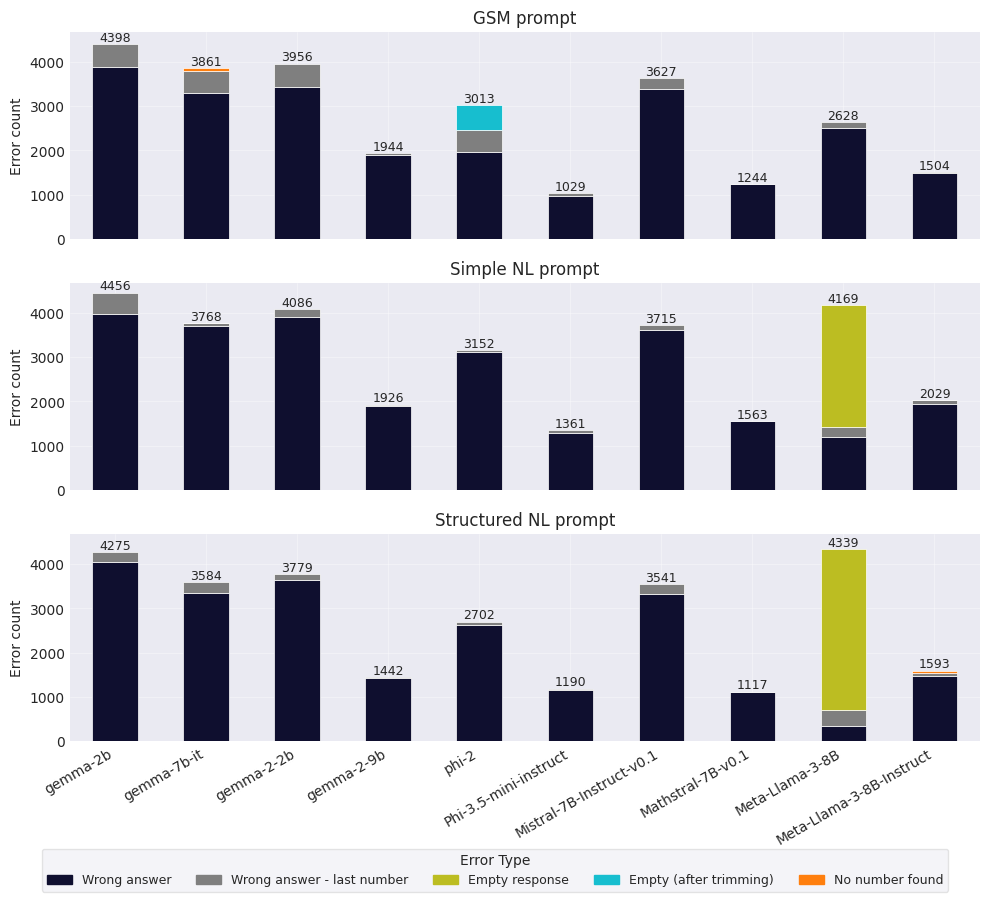

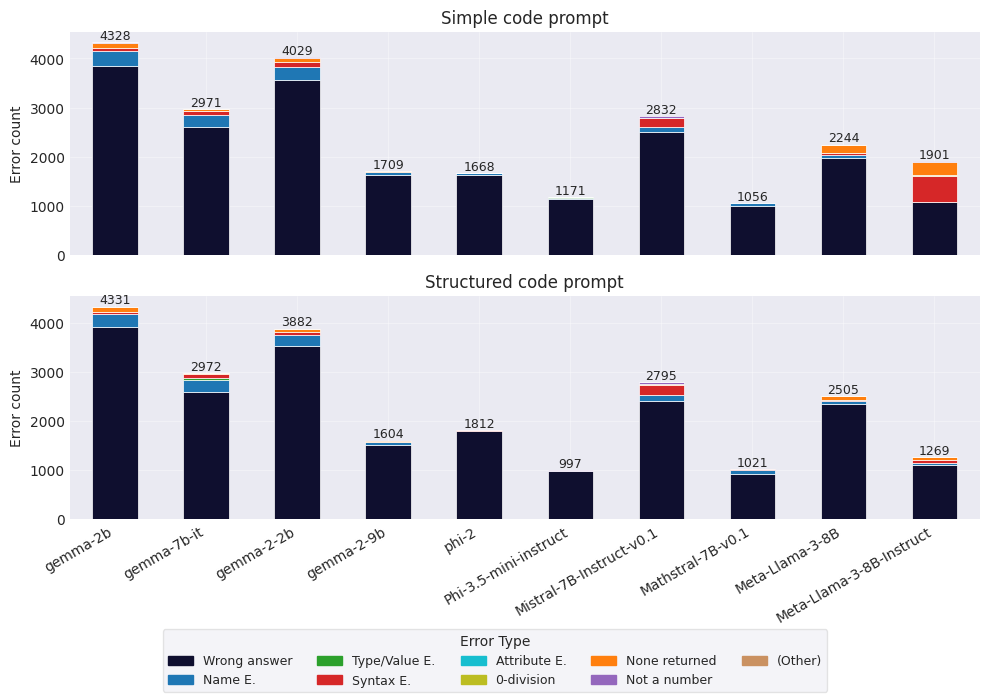

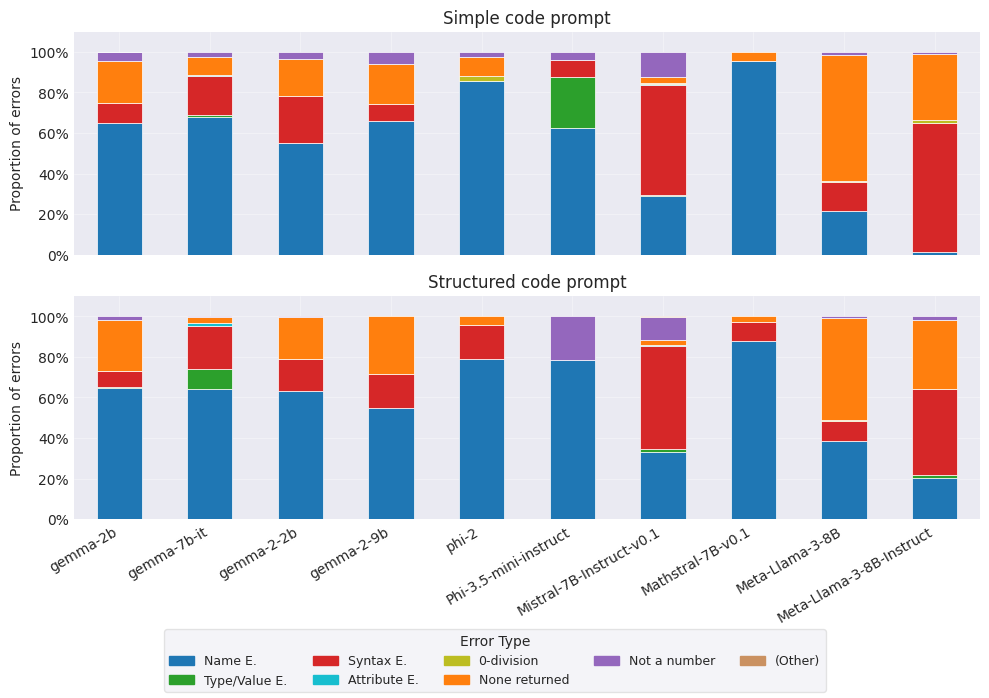

In [51]:
fig = plot_error_bars(nl_errors_df, percentages=False, bottom_margin=0.17, add_bar_labels=True, save_name='errors_nl')

fig = plot_error_bars(code_errors_df, percentages=False, bottom_margin=0.25, add_bar_labels=True, save_name='errors_code')
fig = plot_error_bars(code_errors_df[code_errors_df.error_type != 'NUMERICAL_ERROR'], percentages=True, bottom_margin=0.25, save_name='errors_code_perc')

In [52]:
other_errors = errors_df[errors_df.error_type == 'Other']
other_errors

,prompt,model,id,instance,error_type,question,numerical_result,predicted_numerical_result,full_response
98890,Simple code,gemma-2b,49,39,Other,Hiroshi collects garbage from 5 different apar...,5775.0,NaN,\n apartments_before = 5\n apartments_pe...
124460,Structured code,Mistral-7B-Instruct-v0.1,23,19,Other,Rania is knitting winter wear for her 4 grandc...,284.0,NaN,\n # given:\n grandchildren = 4 # numbe...


In [53]:
for i, row in other_errors.iterrows():
    print(row.full_response)
    print(AnswerExtractor.extract_answer_code(row.full_response))
    print("--------------------------------------\n\n\n")

Error when running extracted function: OverflowError: int too large to convert to float
Error when running extracted function: KeyError: 1



    apartments_before = 5
    apartments_per_complex = 350
    apartments_per_complex_total = apartments_before * apartments_per_complex
    apartments_per_complex_total_75 = apartments_per_complex_total * 0.75
    apartments_per_complex_total_sum = apartments_per_complex_total + apartments_per_complex_total_75
    apartments_per_complex_total_sum_3 = apartments_per_complex_total_sum * 3
    apartments_per_complex_total_sum_3_pay = apartments_per_complex_total_sum_3 * 0.5
    apartments_per_complex_total_sum_3_pay_total = apartments_per_complex_total_sum_3_pay * apartments_per_complex_total_sum_3
    apartments_per_complex_total_sum_3_pay_total_sum = apartments_per_complex_total_sum_3_pay_total + 10000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

In [54]:
code_error_counts = code_errors_df[code_errors_df.error_type!='NUMERICAL_ERROR'].groupby('prompt').error_type.value_counts()
code_error_counts

prompt           error_type         
Simple code      NAME_ERROR             1146
                 SYNTAX_ERROR            979
                 NONE_RETURNED           686
                 NOT_A_NUMBER            105
                 ZERO_DIVISION_ERROR      12
                 TYPE_VALUE_ERROR         11
                 ATTRIBUTE_ERROR           5
                 Other                     1
Structured code  NAME_ERROR             1140
                 SYNTAX_ERROR            480
                 NONE_RETURNED           367
                 NOT_A_NUMBER             64
                 TYPE_VALUE_ERROR         46
                 ATTRIBUTE_ERROR           6
                 ZERO_DIVISION_ERROR       2
                 Other                     1
Name: count, dtype: int64

In [55]:
def cleaunp_table(table: pd.DataFrame):
    keys = list(ERROR_COLOURS.keys())
    if 'Other' not in table.columns:
        keys = keys[:-1]
    table = table.reindex(columns=keys).rename(columns=ERROR_NAMES)

    return table

In [56]:
for prompt in res.keys():
    df_prompt = code_errors_df[code_errors_df.prompt == prompt]

    counts = df_prompt.groupby(['error_type', 'model']).size().reset_index(name='error_count')
    counts_table = counts.pivot(index='model', columns='error_type', values='error_count')
    counts_table = cleaunp_table(counts_table)
    counts_table = counts_table.fillna(0)

    totals = counts_table.sum(axis=0)
    counts_table.loc['Total'] = totals
    counts_table = counts_table.apply(lambda v: v.astype(int).apply(str))
    counts_table.loc[r'Total [\%]'] = (totals / totals.sum() * 100).apply(lambda v: f"{v:.1f}")
    counts_table = counts_table.sort_index(
                key=lambda c: c.map({model: index for index, model in enumerate(MODELS)})
            )


    print(pandas_to_latex(counts_table, label=f"tab:{prompt}-code-error-types", caption=f"Error counts per error type for each model, {prompt} code prompt."))


\begin{table}[t]
\caption{Error counts per error type for each model, GSM code prompt.}
\label{tab:GSM-code-error-types}
\begin{tabular}{lcccccccccccc}
\toprule
 & Wrong answer & Name E. & Type/Value E. & Syntax E. & Attribute E. & 0-division & None returned & Not a number & Wrong answer - last number & Empty response & Empty (after trimming) & No number found \\
\midrule
Total & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
Total [\%] & nan & nan & nan & nan & nan & nan & nan & nan & nan & nan & nan & nan \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[t]
\caption{Error counts per error type for each model, Simple NL code prompt.}
\label{tab:Simple NL-code-error-types}
\begin{tabular}{lcccccccccccc}
\toprule
 & Wrong answer & Name E. & Type/Value E. & Syntax E. & Attribute E. & 0-division & None returned & Not a number & Wrong answer - last number & Empty response & Empty (after trimming) & No number found \\
\midrule
Total & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\

In [57]:
for prompt in res.keys():
    df_prompt = code_errors_df[code_errors_df.prompt == prompt]

    counts = df_prompt.groupby(['error_type', 'model', 'id']).size().reset_index(name='error_count')

    top_indices = counts.groupby(['error_type', 'model'])['error_count'].idxmax()
    top_combinations = counts.loc[top_indices].copy()

    # create the formatted string: "TemplateID (Count)"
    top_combinations['cell_string'] = (
        top_combinations['id'].astype(str) +
        " (" +
        top_combinations['error_count'].astype(str) +
        ")"
    )

    # pivot the table
    top_id_table = top_combinations.pivot(
        index='model',
        columns='error_type',
        values='cell_string'
    )
    top_id_table = cleaunp_table(top_id_table)
    top_id_table = top_id_table.fillna('-')

    print(pandas_to_latex(top_id_table, label=f"tab:{prompt}-code-errors-types-top-id", caption=f"Most frequent template IDs per error type for each model, {prompt} code prompt. Total instances in parentheses."))

\begin{table}[t]
\caption{Most frequent template IDs per error type for each model, GSM code prompt. Total instances in parentheses.}
\label{tab:GSM-code-errors-types-top-id}
\begin{tabular}{lcccccccccccc}
\toprule
 & Wrong answer & Name E. & Type/Value E. & Syntax E. & Attribute E. & 0-division & None returned & Not a number & Wrong answer - last number & Empty response & Empty (after trimming) & No number found \\
\midrule
\bottomrule
\end{tabular}
\end{table}

\begin{table}[t]
\caption{Most frequent template IDs per error type for each model, Simple NL code prompt. Total instances in parentheses.}
\label{tab:Simple NL-code-errors-types-top-id}
\begin{tabular}{lcccccccccccc}
\toprule
 & Wrong answer & Name E. & Type/Value E. & Syntax E. & Attribute E. & 0-division & None returned & Not a number & Wrong answer - last number & Empty response & Empty (after trimming) & No number found \\
\midrule
\bottomrule
\end{tabular}
\end{table}

\begin{table}[t]
\caption{Most frequent template IDs